In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../datasets/mads_synthetic_dataset.csv")
df.head()

,event_id,timestamp,machine,event_type,feature_1,feature_2,feature_3,feature_4,feature_5,ip_address,user_id,process,label
0,EVT-00001,2025-04-13 12:00:00.000000,machine1,data_exfiltration,0.7266,0.7384,-0.1083,0.7594,0.9460,192.168.1.20,U1013,python.exe,malicious
1,EVT-00002,2025-04-13 12:00:11.459098,machine3,normal_activity,0.4288,0.5284,0.4184,0.4572,0.8116,192.168.1.13,U1006,whoami.exe,benign
2,EVT-00003,2025-04-13 12:01:32.010817,machine4,suspicious_file_download,0.5295,0.7131,0.5481,0.9290,-0.0716,192.168.1.30,U1015,svchost.exe,malicious
3,EVT-00004,2025-04-13 12:02:30.953552,machine1,lateral_movement,0.4490,-0.0086,0.9424,0.4923,0.5986,192.168.1.15,U1013,rundll32.exe,malicious
4,EVT-00005,2025-04-13 12:02:48.231682,machine1,c2_connection,0.5861,0.5747,0.3330,0.4468,0.9615,192.168.1.23,U1008,netstat.exe,malicious


In [3]:
from sklearn.model_selection import train_test_split

In [4]:

# Same split as the model notebook: 70/30, stratified, random_state=42
# Splitting on the full df so all columns are preserved in the test set
_, df_test = train_test_split(
    df,
    test_size=0.3,
    random_state=42,
    stratify=df['label']
)

df_test = df_test.reset_index(drop=True)
print(f"Test samples: {len(df_test)}")
df_test.head()


Test samples: 1800


,event_id,timestamp,machine,event_type,feature_1,feature_2,feature_3,feature_4,feature_5,ip_address,user_id,process,label
0,EVT-02859,2025-04-15 12:10:58.821651,machine1,c2_connection,0.4618,0.9587,0.0845,1.3648,1.3822,192.168.1.15,U1001,regsvr32.exe,malicious
1,EVT-02702,2025-04-15 09:32:17.693089,machine3,execution_suspicious_process,0.4154,0.7028,0.6872,0.9114,1.0800,192.168.1.17,U1014,cmd.exe,malicious
2,EVT-00400,2025-04-13 18:39:25.962048,machine4,normal_activity,0.5607,0.2998,0.1374,0.4016,0.9204,192.168.1.20,U1004,powershell.exe,benign
3,EVT-02904,2025-04-15 12:57:40.554191,machine4,c2_connection,0.0499,0.6100,0.1083,0.3275,1.5263,192.168.1.24,U1009,telnet.exe,malicious
4,EVT-03610,2025-04-16 00:18:57.137889,machine2,failed_login_attempts,0.1923,0.4736,0.8595,0.1530,1.2052,192.168.1.15,U1010,python.exe,malicious


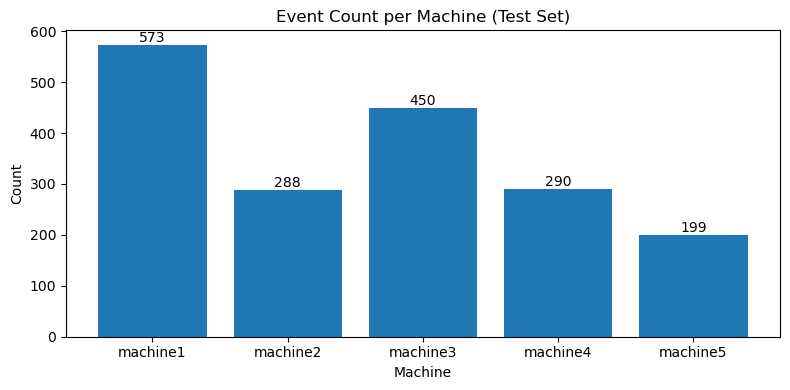

In [5]:

import matplotlib.pyplot as plt

machine_counts = df_test['machine'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(machine_counts.index, machine_counts.values)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        str(int(bar.get_height())),
        ha='center', va='bottom'
    )

ax.set_xlabel("Machine")
ax.set_ylabel("Count")
ax.set_title("Event Count per Machine (Test Set)")
plt.tight_layout()
plt.show()


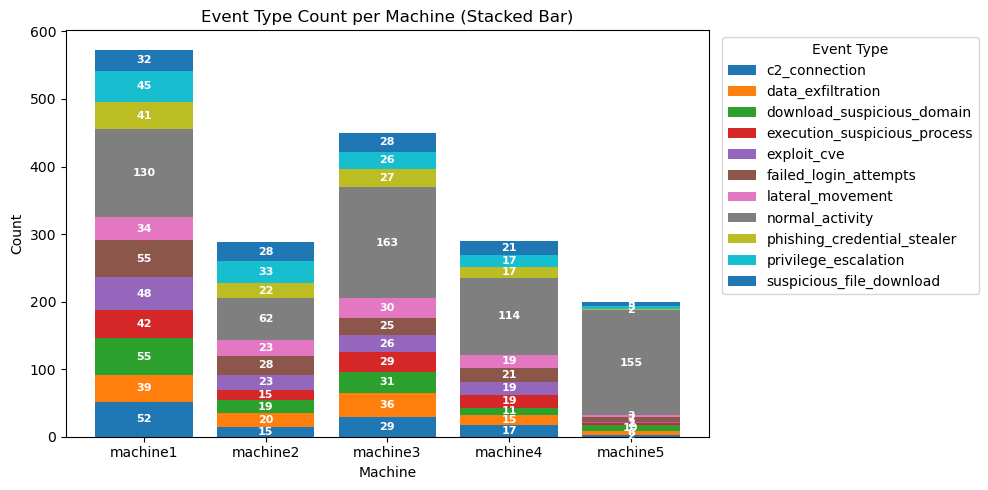

In [6]:

# Stacked bar chart — event_type count per machine, coloured by event_type
pivot = df_test.groupby(['machine', 'event_type']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 5))
bottom = None
for event_type in pivot.columns:
    bars = ax.bar(pivot.index, pivot[event_type], label=event_type, bottom=bottom)
    for bar, b in zip(bars, (bottom if bottom is not None else [0] * len(pivot))):
        height = bar.get_height()
        if height > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                b + height / 2,
                str(int(height)),
                ha='center', va='center', fontsize=8, color='white', fontweight='bold'
            )
    bottom = pivot[event_type].values if bottom is None else bottom + pivot[event_type].values

ax.set_xlabel("Machine")
ax.set_ylabel("Count")
ax.set_title("Event Type Count per Machine (Stacked Bar)")
ax.legend(title="Event Type", bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()


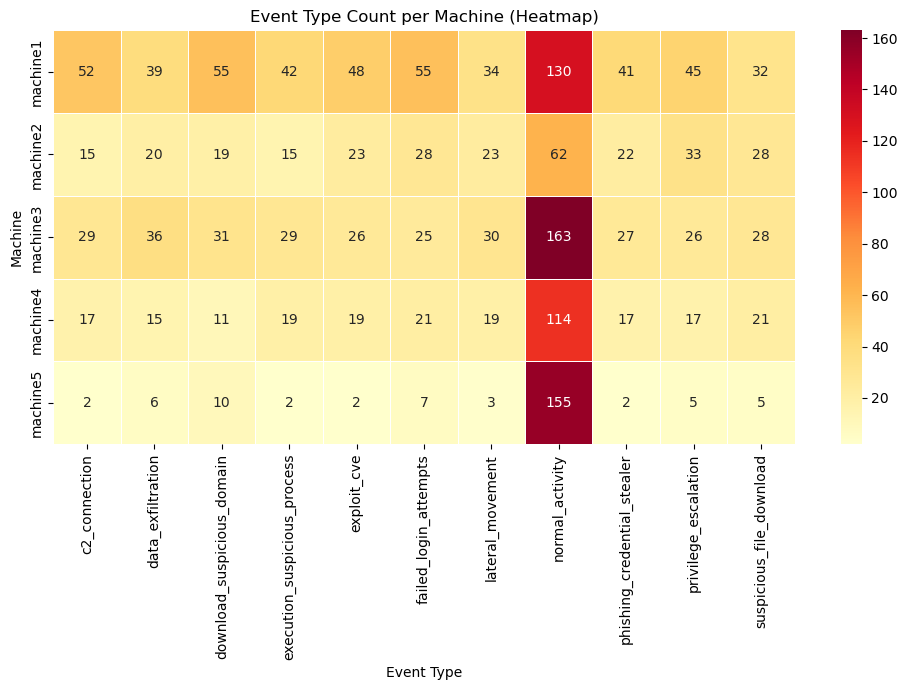

In [7]:

import seaborn as sns

# Heatmap — event_type count per machine
pivot_heat = df_test.groupby(['machine', 'event_type']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(pivot_heat, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_xlabel("Event Type")
ax.set_ylabel("Machine")
ax.set_title("Event Type Count per Machine (Heatmap)")
plt.tight_layout()
plt.show()


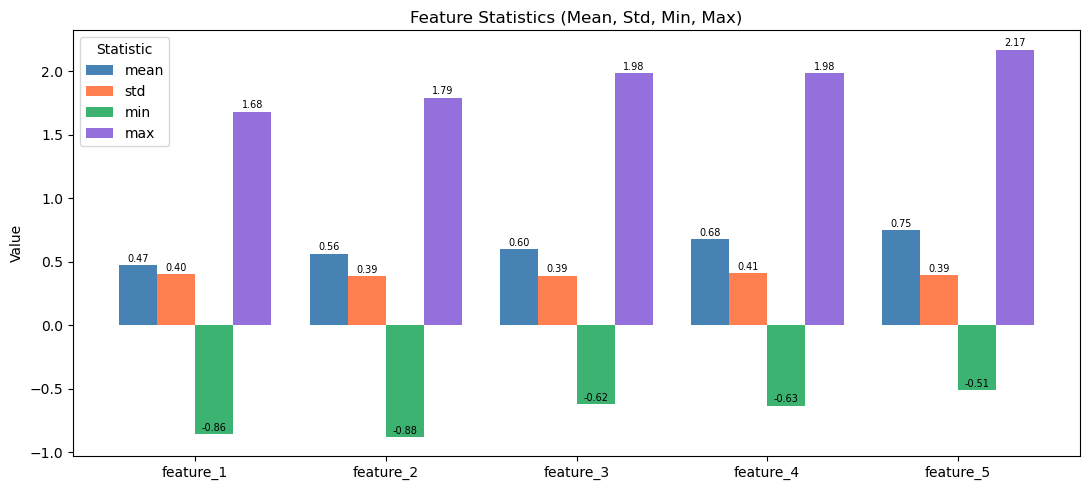

In [8]:

feature_cols = ['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5']
stats = df_test[feature_cols].agg(['mean', 'std', 'min', 'max'])

x = range(len(feature_cols))
stat_labels = ['mean', 'std', 'min', 'max']
colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']
width = 0.2

fig, ax = plt.subplots(figsize=(11, 5))
for i, (stat, color) in enumerate(zip(stat_labels, colors)):
    offsets = [xi + i * width for xi in x]
    bars = ax.bar(offsets, stats.loc[stat], width=width, label=stat, color=color)
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{bar.get_height():.2f}",
            ha='center', va='bottom', fontsize=7
        )

ax.set_xticks([xi + 1.5 * width for xi in x])
ax.set_xticklabels(feature_cols)
ax.set_ylabel("Value")
ax.set_title("Feature Statistics (Mean, Std, Min, Max)")
ax.legend(title="Statistic")
plt.tight_layout()
plt.show()


# MADS Algorithm

Implementation of **Algorithm 1** from the MADS paper.

Each machine maintains its own:
- **AlertList** — a sliding window buffer of recent events
- **MaliciousSamples** counter — high-confidence NN-label disagreements in the current window
- **IncidentList** — confirmed incidents flushed when the counter hits `IncidentThreshold`

Detection uses a **k-NN vote** inside the window: an event increments the counter when the neighbourhood majority label disagrees with the NN-assigned label **and** the vote confidence exceeds **0.60**.


In [9]:
import pickle
import numpy as np
import torch
import torch.nn as nn
from sklearn.neighbors import NearestNeighbors


In [10]:
# ── Load the saved NN model ────────────────────────────────────────────────────
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # project root → finds threat_classifier.py

from threat_classifier import ThreatClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split as _tts

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = ThreatClassifier(input_dim=5)
model.load_state_dict(
    torch.load("../models/saved_models/threat_classifier_nn.pth", map_location=device)
)
model.to(device)
model.eval()   # disable Dropout for inference

# ── Rebuild the scaler (no new NN training) ───────────────────────────────────
# StandardScaler is deterministic: same split parameters → same mean/std as training.
_feature_cols = ['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5']
_df_full      = pd.read_csv("../datasets/mads_synthetic_dataset.csv")
_X_all        = _df_full[_feature_cols].values.astype(np.float32)
_y_all        = (_df_full['label'] == 'malicious').astype(np.float32).values

_X_train, _, _, _ = _tts(_X_all, _y_all, test_size=0.3, random_state=42, stratify=_y_all)

scaler = StandardScaler()
scaler.fit(_X_train)

print(f"Model loaded  ({device})")
print(f"Scaler mean:  {scaler.mean_.round(4)}")
print(f"Scaler std :  {scaler.scale_.round(4)}")


Model loaded  (cpu)
Scaler mean:  [0.4602 0.5596 0.6227 0.6572 0.7431]
Scaler std :  [0.3999 0.4014 0.3988 0.3972 0.4047]


In [11]:
# ── Assign NN labels to every event in the test set ──────────────────────────
# The NN operates on the same five features used during training.
# Raw features → StandardScaler → NN logit → sigmoid → binary label

feature_cols = ['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5']

# Scale raw features with the training-set scaler (identical to training pipeline)
X_raw    = df_test[feature_cols].values.astype(np.float32)
X_scaled = scaler.transform(X_raw).astype(np.float32)

# Run all events through the model in one batch (no_grad for inference)
with torch.no_grad():
    logits      = model(torch.from_numpy(X_scaled).to(device))
    probs       = torch.sigmoid(logits).cpu().numpy()          # (n,) probabilities
    nn_labels   = (probs >= 0.5).astype(int)                   # 1 = malicious, 0 = benign

# Attach NN outputs back to df_test for easy per-event access
df_test = df_test.copy()
df_test['nn_label']      = nn_labels          # NN prediction (int: 0/1)
df_test['nn_prob']       = probs.round(4)     # NN confidence score
df_test['X_scaled']      = list(X_scaled)     # scaled feature vector (for k-NN distances)

label_map = {0: 'benign', 1: 'malicious'}
df_test['nn_label_str'] = df_test['nn_label'].map(label_map)

print(f"Events in test set : {len(df_test)}")
print(f"NN → benign        : {(nn_labels == 0).sum()}")
print(f"NN → malicious     : {(nn_labels == 1).sum()}")
df_test[['machine', 'event_type', 'label', 'nn_label_str', 'nn_prob']].head(8)


Events in test set : 1800
NN → benign        : 540
NN → malicious     : 1260


,machine,event_type,label,nn_label_str,nn_prob
0,machine1,c2_connection,malicious,malicious,0.9772
1,machine3,execution_suspicious_process,malicious,malicious,0.9238
2,machine4,normal_activity,benign,benign,0.3768
3,machine4,c2_connection,malicious,malicious,0.6698
4,machine2,failed_login_attempts,malicious,malicious,0.7744
5,machine1,lateral_movement,malicious,malicious,0.9878
6,machine4,normal_activity,benign,malicious,0.5967
7,machine1,normal_activity,benign,malicious,0.8236


In [17]:
df_test.head()

,event_id,timestamp,machine,event_type,feature_1,feature_2,feature_3,feature_4,feature_5,ip_address,user_id,process,label,nn_label,nn_prob,X_scaled,nn_label_str
0,EVT-02859,2025-04-15 12:10:58.821651,machine1,c2_connection,0.4618,0.9587,0.0845,1.3648,1.3822,192.168.1.15,U1001,regsvr32.exe,malicious,1,0.9772,"[0.0040083686, 0.9942759, -1.3496646, 1.781523...",malicious
1,EVT-02702,2025-04-15 09:32:17.693089,machine3,execution_suspicious_process,0.4154,0.7028,0.6872,0.9114,1.0800,192.168.1.17,U1014,cmd.exe,malicious,1,0.9238,"[-0.11203163, 0.35676852, 0.16175047, 0.640048...",malicious
2,EVT-00400,2025-04-13 18:39:25.962048,machine4,normal_activity,0.5607,0.2998,0.1374,0.4016,0.9204,192.168.1.20,U1004,powershell.exe,benign,0,0.3768,"[0.25134355, -0.64719963, -1.2170051, -0.64341...",benign
3,EVT-02904,2025-04-15 12:57:40.554191,machine4,c2_connection,0.0499,0.6100,0.1083,0.3275,1.5263,192.168.1.24,U1009,telnet.exe,malicious,1,0.6698,"[-1.0260965, 0.12558189, -1.2899803, -0.829972...",malicious
4,EVT-03610,2025-04-16 00:18:57.137889,machine2,failed_login_attempts,0.1923,0.4736,0.8595,0.1530,1.2052,192.168.1.15,U1010,python.exe,malicious,1,0.7744,"[-0.66997385, -0.21422277, 0.59383404, -1.2692...",malicious


In [21]:
# ── detectMaliciousSamples (Algorithm 1, lines 19-29) ────────────────────────
#
# For each event in the AlertList:
#   1. Find its k nearest neighbours within the AlertList (by Euclidean distance
#      in scaled feature space), excluding the event itself.
#   2. Majority-vote those neighbours to get a 'voted label'.
#   3. Compute vote confidence = count(majority) / k.
#   4. If confidence > 0.60  AND  voted label ≠ event's NN label → increment.
#
# Returns the total number of such "disagreement" events.

CONFIDENCE_THRESHOLD = 0.60


def detect_malicious_samples(alert_list: list, k: int) -> int:
    """
    Parameters
    ----------
    alert_list : list of dicts
        Each dict must contain 'nn_label' (int 0/1) and 'X_scaled' (np.ndarray).
    k : int
        Neighbourhood size.  Neighbours are drawn from the AlertList itself.

    Returns
    -------
    int  — number of events whose neighbourhood majority disagrees with nn_label
           at > CONFIDENCE_THRESHOLD confidence.
    """
    n = len(alert_list)

    # Build feature matrix for the current window
    X_window = np.array([e['X_scaled'] for e in alert_list])   # shape (n, 5)

    # k+1 because the query point itself is always the nearest neighbour (dist=0)
    n_neighbors = min(k + 1, n)
    knn = NearestNeighbors(n_neighbors=n_neighbors, metric='euclidean')
    knn.fit(X_window)

    _, indices = knn.kneighbors(X_window)   # indices shape: (n, n_neighbors)

    malicious_count = 0
    for i, event in enumerate(alert_list):
        # Exclude the event itself (index i) from its own neighbourhood
        neighbour_indices = [idx for idx in indices[i] if idx != i][:k]

        if not neighbour_indices:
            continue

        # Majority vote on NN labels of neighbours
        neighbour_labels = [alert_list[j]['nn_label'] for j in neighbour_indices]
        vote       = int(np.round(np.mean(neighbour_labels)))   # 0 or 1
        confidence = neighbour_labels.count(vote) / len(neighbour_labels)

        # Disagreement: neighbours vote differently from the event's NN label
        if confidence > CONFIDENCE_THRESHOLD and vote != event['nn_label']:
        # if confidence > CONFIDENCE_THRESHOLD and vote == 1:   # vote = 1 means majority says "malicious"
            malicious_count += 1

    return malicious_count


print(f"detect_malicious_samples defined  (confidence threshold = {CONFIDENCE_THRESHOLD})")


detect_malicious_samples defined  (confidence threshold = 0.6)


In [22]:
# ── createIncident (Algorithm 1, line 30) ────────────────────────────────────
#
# Packages the current AlertList into a structured incident record that captures:
#   - incidentID and originating machine (for traceability)
#   - time range (first_seen / last_seen) of the window's events
#   - full list of events in the flush window
#   - breakdown of NN-predicted labels in the window

def create_incident(alert_list: list, incident_id: int) -> dict:
    """
    Parameters
    ----------
    alert_list : list of dicts  — events in the current window
    incident_id : int

    Returns
    -------
    dict  — incident record
    """
    timestamps = [e['timestamp'] for e in alert_list]
    nn_labels  = [e['nn_label'] for e in alert_list]

    return {
        'incident_id'       : incident_id,
        'machine'           : alert_list[0]['machine'],
        'first_seen'        : min(timestamps),
        'last_seen'         : max(timestamps),
        'event_count'       : len(alert_list),
        'malicious_in_window': sum(nn_labels),
        'benign_in_window'  : len(nn_labels) - sum(nn_labels),
        'events'            : [e['event_id'] for e in alert_list],
    }


print("create_incident defined")


create_incident defined


In [23]:
# ── MADS main loop (Algorithm 1, lines 1-18) ─────────────────────────────────
#
# The algorithm is applied independently to each machine's event stream.
# Events are sorted by timestamp to respect the temporal order of the stream.
#
# Parameters
# ──────────
# K                 : sliding window size (minimum events before detection runs)
# INCIDENT_THRESHOLD: how many disagreement events trigger a formal incident

K                  = 5
INCIDENT_THRESHOLD = 3

all_incidents = {}   # machine → list of incident dicts

for machine, machine_df in df_test.groupby('machine'):

    # Sort events chronologically to simulate the arriving stream
    stream = machine_df.sort_values('timestamp').to_dict(orient='records')

    # ── Per-machine state (Algorithm 1, line 1) ───────────────────────────────
    alert_list       = []
    incident_list    = []
    malicious_samples = 0
    incident_id       = 1

    # ── Stream ingestion (Algorithm 1, lines 2-17) ───────────────────────────
    for event in stream:

        # Line 3: append every incoming event to the AlertList
        alert_list.append(event)

        # Line 4: detection only fires once we have at least k events
        if len(alert_list) >= K:

            # Line 5-6: count disagreement events in the current window
            new_malicious    = detect_malicious_samples(alert_list, K)
            malicious_samples += new_malicious

            # Line 7: have we crossed the incident threshold?
            if malicious_samples >= INCIDENT_THRESHOLD:

                # Lines 8-10: log the incident
                incident = create_incident(alert_list, incident_id)
                incident_list.append(incident)
                incident_id += 1

                # Lines 11-12: reset counter and flush the window
                malicious_samples = 0
                alert_list.clear()

            else:
                # Line 14: slide the window — drop the oldest event
                alert_list.pop(0)

    all_incidents[machine] = incident_list
    print(f"{machine:10s}  events={len(stream):3d}  incidents={len(incident_list)}")

print(f"\nTotal incidents across all machines: {sum(len(v) for v in all_incidents.values())}")


machine1    events=573  incidents=75
machine2    events=288  incidents=36
machine3    events=450  incidents=61
machine4    events=290  incidents=41
machine5    events=199  incidents=31

Total incidents across all machines: 244


In [16]:
# ── Display results ───────────────────────────────────────────────────────────

import warnings
warnings.filterwarnings('ignore')

rows = []
for machine, incidents in all_incidents.items():
    for inc in incidents:
        rows.append({
            'Incident ID'   : inc['incident_id'],
            'Machine'       : inc['machine'],
            'First Seen'    : inc['first_seen'],
            'Last Seen'     : inc['last_seen'],
            'Events in Window': inc['event_count'],
            'NN Malicious'  : inc['malicious_in_window'],
            'NN Benign'     : inc['benign_in_window'],
            'Event IDs'     : ', '.join(inc['events']),
        })

if rows:
    df_incidents = pd.DataFrame(rows)
    print(f"Incidents raised (k={K}, threshold={INCIDENT_THRESHOLD}):\n")
    display(df_incidents)
else:
    print(f"No incidents raised with k={K}, threshold={INCIDENT_THRESHOLD}.")
    print("Try lowering INCIDENT_THRESHOLD or K in the previous cell.")


Incidents raised (k=5, threshold=3):



,Incident ID,Machine,First Seen,Last Seen,Events in Window,NN Malicious,NN Benign,Event IDs
0,1,machine1,2025-04-13 12:43:25.729815,2025-04-13 13:02:26.649383,5,4,1,"EVT-00048, EVT-00054, EVT-00055, EVT-00057, EV..."
1,2,machine1,2025-04-13 13:53:57.200305,2025-04-13 14:09:11.097186,5,4,1,"EVT-00122, EVT-00123, EVT-00131, EVT-00134, EV..."
2,3,machine1,2025-04-13 14:18:20.003506,2025-04-13 15:07:30.186387,5,3,2,"EVT-00150, EVT-00161, EVT-00187, EVT-00189, EV..."
3,4,machine1,2025-04-13 16:01:45.375553,2025-04-13 17:41:43.403358,5,4,1,"EVT-00240, EVT-00282, EVT-00288, EVT-00307, EV..."
4,5,machine1,2025-04-13 18:09:07.496963,2025-04-13 20:03:39.693207,5,4,1,"EVT-00363, EVT-00427, EVT-00440, EVT-00450, EV..."
...,...,...,...,...,...,...,...,...
239,27,machine5,2025-04-17 00:18:55.763350,2025-04-17 02:51:48.959452,5,2,3,"EVT-05120, EVT-05175, EVT-05196, EVT-05242, EV..."
240,28,machine5,2025-04-17 03:47:14.855983,2025-04-17 05:53:11.006625,5,3,2,"EVT-05323, EVT-05336, EVT-05383, EVT-05416, EV..."
241,29,machine5,2025-04-17 06:40:52.388645,2025-04-17 08:12:09.246215,5,1,4,"EVT-05490, EVT-05503, EVT-05576, EVT-05592, EV..."
242,30,machine5,2025-04-17 09:02:21.792400,2025-04-17 11:31:13.536378,5,3,2,"EVT-05658, EVT-05661, EVT-05681, EVT-05688, EV..."
